In [135]:
from pathlib import Path
from typing import Iterable, List, Union
import re

import numpy as np
import cv2
import pywt
import matplotlib.pyplot as plt

try:
    import tifffile
except ImportError:
    tifffile = None


# ============================================================================
# Filename / frame gathering
# ============================================================================

_LAST_INT_TIF = re.compile(r"(\d+)(?=\.(?:tif|tiff)$)", re.I)


def frame_index(path: Path) -> int:
    """
    Return trailing frame number for sorting TIFF frames.
    Example: image_0051.tif -> 51
    """
    m = _LAST_INT_TIF.search(path.name)
    if not m:
        raise ValueError(f"No trailing integer in filename: {path.name}")
    return int(m.group(1))


def _gather_frames(frames_dir: Path) -> List[Path]:
    """
    Collect frames from a directory.

    If any TIFF filenames end in a trailing integer, sort numerically.
    Otherwise sort alphabetically.
    """
    exts = ("*.tif", "*.tiff", "*.png", "*.jpg", "*.jpeg", "*.bmp")
    paths: List[Path] = []
    for ext in exts:
        paths.extend(frames_dir.glob(ext))

    if not paths:
        raise ValueError(f"No image files found in {frames_dir}")

    numeric = [p for p in paths if _LAST_INT_TIF.search(p.name)]
    if numeric:
        return sorted(numeric, key=frame_index)

    return sorted(paths, key=lambda p: p.name.lower())


# ============================================================================
# Image loading / writing
# ============================================================================

def load_gray_native(path: Union[str, Path]) -> np.ndarray:
    """
    Load an image without changing its native bit depth.

    Returns:
        grayscale ndarray with original integer storage dtype when possible
        usually uint8 or uint16
    """
    p = Path(path)

    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)

    if img is None:
        if tifffile is None:
            raise IOError(
                f"Could not decode image with OpenCV, and tifffile is not installed: {p}"
            )
        try:
            img = tifffile.imread(str(p))
        except Exception as e:
            raise IOError(f"Could not decode image: {p}") from e

    img = np.asarray(img)

    if img.ndim == 3:
        if img.shape[2] == 1:
            img = img[:, :, 0]
        elif img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return img


def write_image(path: Union[str, Path], img: np.ndarray) -> Path:
    """
    Write an image to disk.

    - uint8 / uint16: uses OpenCV
    - float TIFF: uses tifffile when available
    """
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)

    if p.suffix == "":
        p = p.with_suffix(".tif")

    is_tiff = p.suffix.lower() in (".tif", ".tiff")

    if img.dtype.kind == "f" and is_tiff and tifffile is not None:
        tifffile.imwrite(str(p), img)
        return p

    ok = cv2.imwrite(str(p), img)
    if not ok:
        raise IOError(f"Failed to write image: {p}")

    return p


def to_display_u8(img: np.ndarray) -> np.ndarray:
    """
    Convert any grayscale image to displayable uint8.
    Useful for OpenCV windows and video writing.
    """
    arr = img.astype(np.float32)
    mn = float(arr.min())
    mx = float(arr.max())

    if mx - mn < 1e-12:
        return np.full(arr.shape, 128, dtype=np.uint8)

    arr = 255.0 * (arr - mn) / (mx - mn)
    return np.clip(arr, 0, 255).astype(np.uint8)


# ============================================================================
# Storage mode detection and conversion
# ============================================================================

def detect_storage_mode(img: np.ndarray) -> str:
    """
    Detect likely image storage mode.

    Returns one of:
        '8bit'
        '12in16_shifted'   -> Phantom-style 12-bit values left-shifted by 4
        '12in16_lowrange'  -> uint16 storage but only 0..4095 used
        '16bit'
    """
    if img.dtype == np.uint8:
        return "8bit"

    if img.dtype != np.uint16:
        raise ValueError(f"Unsupported dtype for detection: {img.dtype}")

    mx = int(img.max())

    # Strong hint of 12-bit data stored as value << 4
    if np.all((img & 15) == 0):
        return "12in16_shifted"

    # 12-bit values stored directly inside uint16 container
    if mx <= 4095:
        return "12in16_lowrange"

    return "16bit"


def storage_mode_info(mode: str) -> tuple[int, int, np.dtype]:
    """
    Return:
        nominal_bits, nominal_max, storage_dtype
    """
    if mode == "8bit":
        return 8, 255, np.uint8
    if mode == "12in16_shifted":
        return 12, 4095, np.uint16
    if mode == "12in16_lowrange":
        return 12, 4095, np.uint16
    if mode == "16bit":
        return 16, 65535, np.uint16
    raise ValueError(f"Unknown storage mode: {mode}")


def decode_to_nominal(img_native: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert stored image data into nominal working space for processing.

    Examples:
    - 8bit stays 0..255
    - 12in16_shifted becomes 0..4095 by right shift 4
    - 12in16_lowrange stays 0..4095
    - 16bit stays 0..65535
    """
    if mode == "8bit":
        return img_native.astype(np.float32)

    if mode == "12in16_shifted":
        return (img_native.astype(np.uint16) >> 4).astype(np.float32)

    if mode == "12in16_lowrange":
        return img_native.astype(np.float32)

    if mode == "16bit":
        return img_native.astype(np.float32)

    raise ValueError(f"Unknown storage mode: {mode}")


def encode_from_nominal(img_nominal: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert processed nominal-space data back into the same storage style
    as the original input.
    """
    nominal_bits, nominal_max, storage_dtype = storage_mode_info(mode)

    arr = np.clip(np.round(img_nominal), 0, nominal_max)

    if mode == "8bit":
        return arr.astype(np.uint8)

    if mode == "12in16_shifted":
        return (arr.astype(np.uint16) << 4)

    if mode == "12in16_lowrange":
        return arr.astype(np.uint16)

    if mode == "16bit":
        return arr.astype(np.uint16)

    raise ValueError(f"Unknown storage mode: {mode}")


def load_gray_nominal(
    path: Union[str, Path],
    *,
    storage_mode_override: str | None = None,
    return_mode: bool = False,
) -> np.ndarray | tuple[np.ndarray, str]:
    """
    Load an image and convert it into nominal processing space.

    If storage_mode_override is given, that mode is used instead of auto-detect.
    """
    native = load_gray_native(path)
    mode = storage_mode_override if storage_mode_override is not None else detect_storage_mode(native)
    nominal = decode_to_nominal(native, mode)

    if return_mode:
        return nominal, mode
    return nominal


def inspect_image_storage(path: Union[str, Path]) -> None:
    """
    Quick diagnostic for one image.
    """
    native = load_gray_native(path)
    mode = detect_storage_mode(native)
    print(f"path: {path}")
    print(f"dtype: {native.dtype}")
    print(f"min: {native.min()}")
    print(f"max: {native.max()}")
    if native.dtype == np.uint16:
        print(f"unique mod 16 (first 20): {np.unique(native % 16)[:20]}")
    print(f"detected storage mode: {mode}")


# ============================================================================
# ROI helpers
# ============================================================================

def crop_image(
    img: np.ndarray,
    crop_box: tuple[int, int, int, int] | None
) -> np.ndarray:
    """
    Crop image using (x, y, w, h).
    If crop_box is None, return full image.
    """
    if crop_box is None:
        return img

    x, y, w, h = crop_box
    return img[y:y + h, x:x + w]


def select_crop_region(image_path: Union[str, Path]) -> tuple[int, int, int, int]:
    """
    Select the crop region from a single image or the first image in a directory.
    """
    p = Path(image_path)

    if p.is_dir():
        frames = _gather_frames(p)
        if not frames:
            raise ValueError(f"No images found in directory: {p}")
        image_path = frames[0]
    else:
        image_path = p

    img = to_display_u8(load_gray_nominal(image_path))

    win = "Crop Baseline"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1200, 800)

    print("Select crop region and press ENTER or SPACE when done. Press ESC to cancel.")
    r = cv2.selectROI(win, img, showCrosshair=True)
    cv2.destroyAllWindows()

    x, y, w, h = map(int, r)
    if w == 0 or h == 0:
        raise ValueError("No crop region selected.")

    print(f"Crop selected: x={x}, y={y}, w={w}, h={h}")
    return x, y, w, h


def select_exposure_region(image_path: Union[str, Path]) -> tuple[int, int, int, int]:
    """
    Select the stable-light ROI used for exposure matching.
    """
    p = Path(image_path)

    if p.is_dir():
        frames = _gather_frames(p)
        if not frames:
            raise ValueError(f"No images found in directory: {p}")
        image_path = frames[0]
    else:
        image_path = p

    img = to_display_u8(load_gray_nominal(image_path))

    win = "Crop Exposure ROI (Stable Light Source)"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1200, 800)

    print("Select exposure ROI and press ENTER or SPACE when done. Press ESC to cancel.")
    r = cv2.selectROI(win, img, showCrosshair=True)
    cv2.destroyAllWindows()

    x, y, w, h = map(int, r)
    if w == 0 or h == 0:
        raise ValueError("No exposure ROI selected.")

    print(f"Exposure ROI selected: x={x}, y={y}, w={w}, h={h}")
    return x, y, w, h


# ============================================================================
# FFT bandstop filtering
# ============================================================================

def make_ky_bandstop_mask(
    shape: tuple[int, int],
    ky_targets: list[float],
    *,
    sigma_ky: float = 0.005,
) -> np.ndarray:
    """
    Build multiplicative FFT mask that removes energy at ky = ±k0 for all kx.
    Works in fftshifted coordinates.
    """
    h, w = shape
    ky = np.fft.fftshift(np.fft.fftfreq(h, d=1.0))
    ky_grid = ky[:, None]

    mask = np.ones((h, w), dtype=np.float32)

    for k0 in ky_targets:
        k0 = float(abs(k0))
        if k0 < 1e-12:
            continue

        g_pos = np.exp(-0.5 * ((ky_grid - k0) / sigma_ky) ** 2)
        g_neg = np.exp(-0.5 * ((ky_grid + k0) / sigma_ky) ** 2)

        notch = (1.0 - g_pos) * (1.0 - g_neg)
        mask *= notch.astype(np.float32)

    return mask


def ky_bandstop_filter_image(
    img: np.ndarray,
    ky_targets: list[float],
    *,
    sigma_ky: float | None = None,
    detrend: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Remove selected ky frequencies for all kx using FFT bandstop filtering.
    Returns:
        filtered_image, mask
    """
    x = img.astype(np.float32)

    if detrend:
        x = x - np.mean(x)

    if sigma_ky is None:
        sigma_ky = 2.0 / x.shape[0]

    F = np.fft.fft2(x)
    Fshift = np.fft.fftshift(F)

    mask = make_ky_bandstop_mask(x.shape, ky_targets, sigma_ky=sigma_ky)
    Ffilt = Fshift * mask

    out = np.fft.ifft2(np.fft.ifftshift(Ffilt))
    out = np.real(out).astype(np.float32)

    return out, mask


def maybe_apply_ky_filter(
    img: np.ndarray,
    *,
    apply_ky_filter: bool,
    ky_targets: list[float] | None,
    ky_sigma: float | None,
) -> np.ndarray:
    """
    Conditionally apply the ky bandstop filter.
    """
    if not apply_ky_filter:
        return img.astype(np.float32)

    if not ky_targets:
        raise ValueError("apply_ky_filter=True requires ky_targets=[...]")

    filtered, _ = ky_bandstop_filter_image(
        img,
        ky_targets=ky_targets,
        sigma_ky=ky_sigma,
    )
    return filtered


# ============================================================================
# Core processing helpers
# ============================================================================

def subtract_background_signed(frame: np.ndarray, baseline: np.ndarray) -> np.ndarray:
    """
    Signed background subtraction.
    Positive means frame brighter than baseline.
    Negative means frame darker than baseline.
    """
    return frame.astype(np.float32) - baseline.astype(np.float32)


def contrast_stretch_signed(img: np.ndarray, nominal_max: int) -> np.ndarray:
    """
    Symmetric signed contrast stretch.

    Mapping:
        -peak -> 0
         0    -> midpoint
        +peak -> nominal_max

    This preserves sign visibility in the saved image.
    """
    x = img.astype(np.float32)
    peak = max(abs(float(x.min())), abs(float(x.max())))

    midpoint = nominal_max / 2.0
    half_range = nominal_max / 2.0

    if peak < 1e-12:
        stretched = np.full_like(x, midpoint, dtype=np.float32)
    else:
        stretched = midpoint + (x / peak) * half_range

    return np.clip(np.round(stretched), 0, nominal_max)


def wvlt_denoise(frame: np.ndarray, threshold: float = 0.025) -> np.ndarray:
    """
    Wavelet denoising using soft thresholding of 2D wavelet coefficients.
    """
    frame = frame.astype(np.float32)
    wavelet = pywt.Wavelet("rbio5.5")

    coeffs = pywt.wavedec2(frame, wavelet)

    cA = coeffs[0]
    cA_thr = pywt.threshold(cA, threshold, mode="soft")

    detail_coeffs_thr = []
    for cH, cV, cD in coeffs[1:]:
        cH_t = pywt.threshold(cH, threshold, mode="soft")
        cV_t = pywt.threshold(cV, threshold, mode="soft")
        cD_t = pywt.threshold(cD, threshold, mode="soft")
        detail_coeffs_thr.append((cH_t, cV_t, cD_t))

    coeffs_thr = [cA_thr] + detail_coeffs_thr

    rec = pywt.waverec2(coeffs_thr, wavelet)
    rec = rec[:frame.shape[0], :frame.shape[1]]
    return rec.astype(np.float32)


# ============================================================================
# Baseline handling
# ============================================================================

def compute_mean_baseline(
    baseline_dir: Union[str, Path],
    crop_box: tuple[int, int, int, int] | None,
    *,
    storage_mode_override: str | None = None,
    apply_ky_filter: bool = False,
    ky_targets: list[float] | None = None,
    ky_sigma: float | None = None,
) -> np.ndarray:
    """
    Load all baseline images, decode to nominal space, optionally filter,
    crop, and return the mean baseline image.
    """
    baseline_dir = Path(baseline_dir)
    paths = _gather_frames(baseline_dir)

    mean_img = None
    count = 0

    for p in paths:
        img = load_gray_nominal(p, storage_mode_override=storage_mode_override)
        img = maybe_apply_ky_filter(
            img,
            apply_ky_filter=apply_ky_filter,
            ky_targets=ky_targets,
            ky_sigma=ky_sigma,
        )
        img = crop_image(img, crop_box)

        if mean_img is None:
            mean_img = np.zeros_like(img, dtype=np.float32)

        mean_img += img
        count += 1

    mean_img /= float(count)
    print(f"Mean baseline computed from {count} frames")
    return mean_img


# ============================================================================
# Save processed output
# ============================================================================

def save_processed_result(
    save_path: Union[str, Path],
    diff: np.ndarray,
    *,
    apply_contrast_stretch: bool,
    same_storage_output: bool,
    output_storage_mode: str,
) -> np.ndarray | None:
    """
    Save one processed result.

    If apply_contrast_stretch=True:
        - signed stretch in nominal space
        - then encode back into the same storage style as input
          when same_storage_output=True

    If apply_contrast_stretch=False:
        - save raw float32 signed diff as TIFF

    Returns:
        saved_image_array if an integer display image was saved
        None if raw float32 diff was saved instead
    """
    save_path = Path(save_path)

    if apply_contrast_stretch:
        if same_storage_output:
            _, nominal_max, _ = storage_mode_info(output_storage_mode)
            stretched_nominal = contrast_stretch_signed(diff, nominal_max=nominal_max)
            proc = encode_from_nominal(stretched_nominal, output_storage_mode)
        else:
            proc = to_display_u8(diff)

        write_image(save_path, proc)
        return proc

    raw_path = save_path.with_suffix(".tif")
    write_image(raw_path, diff.astype(np.float32))
    return None


# ============================================================================
# Video writing
# ============================================================================

def write_video_from_frames(
    frames_dir: Union[str, Path],
    video_path: Union[str, Path] | None = None,
    *,
    fps: int = 30,
    frame_repeat: int = 1,
    codec: str = "mp4v",
    pattern_exts: Iterable[str] = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"),
) -> Path:
    """
    Create a video from image frames in frames_dir.

    Ways to make the video slower / longer:
    1. Lower fps
    2. Increase frame_repeat

    Duration scales like:
        duration ~ N_frames * frame_repeat / fps
    """
    frames_dir = Path(frames_dir)

    if video_path is None:
        video_path = frames_dir / f"{frames_dir.name}.mp4"
    else:
        video_path = Path(video_path)

    if frame_repeat < 1:
        raise ValueError("frame_repeat must be >= 1")

    paths = [p for p in frames_dir.iterdir() if p.suffix.lower() in pattern_exts]
    if not paths:
        raise ValueError(f"No frames found in: {frames_dir}")

    try:
        paths = sorted(paths, key=frame_index)
    except Exception:
        paths = sorted(paths, key=lambda p: p.name.lower())

    first = load_gray_native(paths[0])
    if first.ndim != 2:
        raise ValueError("Video writer expects grayscale frames after loading.")
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(str(video_path), fourcc, fps, (w, h), True)

    if not writer.isOpened():
        print(f"[video] Primary codec '{codec}' failed for {video_path}, trying MJPG/.avi fallback")
        fallback_path = video_path.with_suffix(".avi")
        fourcc_fallback = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(fallback_path), fourcc_fallback, fps, (w, h), True)

        if not writer.isOpened():
            raise IOError(f"Could not open VideoWriter for either {video_path} or {fallback_path}")

        video_path = fallback_path
        print(f"[video] Using MJPG fallback at {fallback_path}")

    for i, p in enumerate(paths, start=1):
        img = load_gray_native(p)

        if img.ndim != 2:
            raise ValueError(f"Expected grayscale frame for video: {p.name}")

        if img.shape[:2] != (h, w):
            raise ValueError(
                f"Frame size mismatch for {p.name}: expected {(w, h)}, "
                f"got {(img.shape[1], img.shape[0])}"
            )

        img_u8 = to_display_u8(img)
        bgr = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)

        for _ in range(frame_repeat):
            writer.write(bgr)

        if (i % 100) == 0 or i == len(paths):
            print(f"[video] {i}/{len(paths)} source frames added...")

    writer.release()
    print(f"Video written: {video_path}")
    return video_path


# ============================================================================
# Main pipeline
# ============================================================================

def process_schlieren(
    schlieren_frame: Union[str, Path],
    baseline_dir: Union[str, Path],
    out_path: Union[str, Path],
    *,
    baseline_single_path: Union[str, Path] | None = None,
    baseline_mode: str = "mean",  # "mean" | "single" | "first" | "paired"
    use_existing_crop: tuple[int, int, int, int] | None = None,
    skip_crop: bool = False,

    storage_mode_override: str | None = None,
    # Set this if you want to force one mode for all inputs, for example:
    # "8bit", "12in16_shifted", "12in16_lowrange", "16bit"
    # Leave None for auto-detect.

    apply_ky_filter: bool = False,
    ky_targets: list[float] | None = None,
    ky_sigma: float | None = None,

    exposure_match_mode: str = "none",  # "none" | "option1" | "option2" | "option3"
    exposure_eps: float = 1e-6,
    exposure_roi: tuple[int, int, int, int] | None = None,

    apply_contrast_stretch: bool = True,
    same_storage_output: bool = True,

    apply_wavelet_denoise: bool = True,
    wavelet_threshold: float = 1.0,

    make_video: bool = False,
    video_fps: int = 30,
    video_frame_repeat: int = 1,
    video_codec: str = "mp4v",
) -> tuple[np.ndarray, np.ndarray | None, tuple[int, int, int, int] | None]:
    """
    Process one schlieren frame or a directory of frames.

    Returns:
        last_diff  : last raw signed diff in nominal processing space
        last_proc  : last saved processed integer image, or None if raw float32 was saved
        crop_box   : crop box used, or None if cropping was skipped
    """
    baseline_dir = Path(baseline_dir)
    schlieren_frame = Path(schlieren_frame)
    out_path = Path(out_path)

    if not baseline_dir.exists():
        raise FileNotFoundError(f"Baseline directory does not exist: {baseline_dir}")

    if not schlieren_frame.exists():
        raise FileNotFoundError(f"Schlieren input does not exist: {schlieren_frame}")

    # ----------------------------------------------------------------------
    # Determine output storage style from the first schlieren image
    # ----------------------------------------------------------------------
    if storage_mode_override is not None:
        output_storage_mode = storage_mode_override
    else:
        if schlieren_frame.is_file():
            ref_native = load_gray_native(schlieren_frame)
        elif schlieren_frame.is_dir():
            ref_native = load_gray_native(_gather_frames(schlieren_frame)[0])
        else:
            raise FileNotFoundError(f"Schlieren path is neither a file nor directory: {schlieren_frame}")

        output_storage_mode = detect_storage_mode(ref_native)

    nominal_bits, nominal_max, storage_dtype = storage_mode_info(output_storage_mode)
    print(
        f"Output storage mode: {output_storage_mode} | "
        f"nominal bits = {nominal_bits} | nominal max = {nominal_max} | "
        f"storage dtype = {storage_dtype.__name__}"
    )

    # ----------------------------------------------------------------------
    # Crop region
    # ----------------------------------------------------------------------
    if skip_crop:
        crop_box = None
        print("Cropping disabled. Using full frame.")
    elif use_existing_crop is None:
        crop_box = select_crop_region(baseline_dir)
    else:
        crop_box = use_existing_crop
        print(f"Reusing crop box: {crop_box}")

    # ----------------------------------------------------------------------
    # Validate options
    # ----------------------------------------------------------------------
    baseline_mode = baseline_mode.lower().strip()
    exposure_match_mode = exposure_match_mode.lower().strip()

    valid_baseline_modes = {"mean", "single", "first", "paired"}
    valid_exposure_modes = {"none", "option1", "option2", "option3"}

    if baseline_mode not in valid_baseline_modes:
        raise ValueError("baseline_mode must be one of: 'mean', 'single', 'first', 'paired'")

    if exposure_match_mode not in valid_exposure_modes:
        raise ValueError("exposure_match_mode must be one of: 'none', 'option1', 'option2', 'option3'")

    if exposure_match_mode != "none" and baseline_mode != "paired":
        raise ValueError("exposure_match_mode is only supported when baseline_mode == 'paired'")

    if exposure_match_mode == "option3":
        if exposure_roi is None:
            exposure_roi = select_exposure_region(baseline_dir)
        else:
            print(f"Reusing exposure ROI: {exposure_roi}")

    # ----------------------------------------------------------------------
    # Prepare baseline source
    # ----------------------------------------------------------------------
    baseline_img: np.ndarray | None = None
    baseline_frames: List[Path] | None = None

    if baseline_mode == "mean":
        baseline_img = compute_mean_baseline(
            baseline_dir,
            crop_box,
            storage_mode_override=storage_mode_override,
            apply_ky_filter=apply_ky_filter,
            ky_targets=ky_targets,
            ky_sigma=ky_sigma,
        )

    elif baseline_mode == "first":
        first_path = _gather_frames(baseline_dir)[0]
        baseline_img = load_gray_nominal(first_path, storage_mode_override=storage_mode_override)
        baseline_img = maybe_apply_ky_filter(
            baseline_img,
            apply_ky_filter=apply_ky_filter,
            ky_targets=ky_targets,
            ky_sigma=ky_sigma,
        )
        baseline_img = crop_image(baseline_img, crop_box)
        print(f"Using FIRST baseline frame: {first_path.name}")

    elif baseline_mode == "single":
        if baseline_single_path is None:
            raise ValueError("baseline_mode='single' requires baseline_single_path=...")

        baseline_single_path = Path(baseline_single_path)
        if not baseline_single_path.exists():
            raise FileNotFoundError(f"Baseline single frame not found: {baseline_single_path}")

        baseline_img = load_gray_nominal(baseline_single_path, storage_mode_override=storage_mode_override)
        baseline_img = maybe_apply_ky_filter(
            baseline_img,
            apply_ky_filter=apply_ky_filter,
            ky_targets=ky_targets,
            ky_sigma=ky_sigma,
        )
        baseline_img = crop_image(baseline_img, crop_box)
        print(f"Using SINGLE baseline frame: {baseline_single_path.name}")

    elif baseline_mode == "paired":
        if not schlieren_frame.is_dir():
            raise ValueError("baseline_mode='paired' requires schlieren_frame to be a directory of frames.")
        baseline_frames = _gather_frames(baseline_dir)

    # ----------------------------------------------------------------------
    # Single frame mode
    # ----------------------------------------------------------------------
    if schlieren_frame.is_file():
        if baseline_mode == "paired":
            raise ValueError("baseline_mode='paired' only works when schlieren_frame is a directory.")

        frame = load_gray_nominal(schlieren_frame, storage_mode_override=storage_mode_override)
        frame = maybe_apply_ky_filter(
            frame,
            apply_ky_filter=apply_ky_filter,
            ky_targets=ky_targets,
            ky_sigma=ky_sigma,
        )
        frame_cropped = crop_image(frame, crop_box)

        assert baseline_img is not None
        if frame_cropped.shape != baseline_img.shape:
            raise ValueError(
                f"Shape mismatch after crop: frame {frame_cropped.shape}, baseline {baseline_img.shape}"
            )

        diff = subtract_background_signed(frame_cropped, baseline_img)

        if apply_wavelet_denoise:
            diff = wvlt_denoise(diff, threshold=wavelet_threshold)

        save_path = out_path if out_path.suffix else out_path.with_suffix(".tif")

        proc = save_processed_result(
            save_path,
            diff,
            apply_contrast_stretch=apply_contrast_stretch,
            same_storage_output=same_storage_output,
            output_storage_mode=output_storage_mode,
        )

        return diff, proc, crop_box

    # ----------------------------------------------------------------------
    # Batch mode
    # ----------------------------------------------------------------------
    if schlieren_frame.is_dir():
        frames_dir = schlieren_frame
        schlieren_frames = _gather_frames(frames_dir)

        out_dir = out_path
        out_dir.mkdir(parents=True, exist_ok=True)

        print(f"Batch processing {len(schlieren_frames)} frames from {frames_dir} into {out_dir}")

        if baseline_mode == "paired":
            assert baseline_frames is not None
            if len(baseline_frames) != len(schlieren_frames):
                raise ValueError(
                    f"paired mode requires equal counts: baseline={len(baseline_frames)} "
                    f"schlieren={len(schlieren_frames)}"
                )

        # Exposure option2 needs a reference mean across all schlieren crops
        s_ref: float | None = None
        if exposure_match_mode == "option2":
            s_means = []
            for s_path in schlieren_frames:
                s_tmp = load_gray_nominal(s_path, storage_mode_override=storage_mode_override)
                s_tmp = maybe_apply_ky_filter(
                    s_tmp,
                    apply_ky_filter=apply_ky_filter,
                    ky_targets=ky_targets,
                    ky_sigma=ky_sigma,
                )
                s_tmp = crop_image(s_tmp, crop_box)
                s_means.append(float(s_tmp.mean()))

            s_ref = float(np.mean(s_means))
            print(f"[exposure option2] s_ref = {s_ref:.6f}")

        last_diff: np.ndarray | None = None
        last_proc: np.ndarray | None = None

        for i, s_path in enumerate(schlieren_frames):
            s = load_gray_nominal(s_path, storage_mode_override=storage_mode_override)
            s = maybe_apply_ky_filter(
                s,
                apply_ky_filter=apply_ky_filter,
                ky_targets=ky_targets,
                ky_sigma=ky_sigma,
            )
            s_crop = crop_image(s, crop_box)

            if baseline_mode == "paired":
                assert baseline_frames is not None
                b_path = baseline_frames[i]

                b = load_gray_nominal(b_path, storage_mode_override=storage_mode_override)
                b = maybe_apply_ky_filter(
                    b,
                    apply_ky_filter=apply_ky_filter,
                    ky_targets=ky_targets,
                    ky_sigma=ky_sigma,
                )
                b_crop = crop_image(b, crop_box)

                if s_crop.shape != b_crop.shape:
                    raise ValueError(
                        f"Shape mismatch after crop at i={i}: schlieren {s_crop.shape}, "
                        f"baseline {b_crop.shape} ({s_path.name} vs {b_path.name})"
                    )

                if exposure_match_mode == "none":
                    diff = subtract_background_signed(s_crop, b_crop)

                else:
                    if exposure_match_mode == "option1":
                        # alpha from cropped frame pair
                        s_mean = float(s_crop.mean())
                        b_mean = float(b_crop.mean())

                    elif exposure_match_mode == "option3":
                        # alpha from stable-light ROI on full nominal images
                        assert exposure_roi is not None
                        s_roi = crop_image(s, exposure_roi)
                        b_roi = crop_image(b, exposure_roi)
                        s_mean = float(s_roi.mean())
                        b_mean = float(b_roi.mean())

                    else:
                        # option2
                        assert s_ref is not None
                        s_mean = s_ref
                        b_mean = float(b_crop.mean())

                    if abs(b_mean) < exposure_eps:
                        alpha = 1.0
                    else:
                        alpha = float(s_mean / b_mean)

                    diff = s_crop.astype(np.float32) - alpha * b_crop.astype(np.float32)

            else:
                assert baseline_img is not None

                if s_crop.shape != baseline_img.shape:
                    raise ValueError(
                        f"Shape mismatch after crop for {s_path.name}: "
                        f"frame {s_crop.shape}, baseline {baseline_img.shape}"
                    )

                diff = subtract_background_signed(s_crop, baseline_img)

            if apply_wavelet_denoise:
                diff = wvlt_denoise(diff, threshold=wavelet_threshold)

            save_path = out_dir / f"{s_path.stem}_proc.tif"

            proc = save_processed_result(
                save_path,
                diff,
                apply_contrast_stretch=apply_contrast_stretch,
                same_storage_output=same_storage_output,
                output_storage_mode=output_storage_mode,
            )

            last_diff = diff
            last_proc = proc

            if ((i + 1) % 25 == 0) or (i + 1 == len(schlieren_frames)):
                print(f"[{i + 1}/{len(schlieren_frames)}] processed {s_path.name}")

        print(f"Finished batch. {len(schlieren_frames)} frames written to {out_dir}")

        if make_video:
            ext = ".mp4" if video_codec.lower() != "mjpg" else ".avi"
            video_path = write_video_from_frames(
                out_dir,
                video_path=out_dir / f"{out_dir.name}{ext}",
                fps=video_fps,
                frame_repeat=video_frame_repeat,
                codec=video_codec,
            )
            print(f"Video saved at: {video_path}")

        return last_diff, last_proc, crop_box

    raise FileNotFoundError(f"Schlieren path is neither a file nor directory: {schlieren_frame}")

In [137]:
"""
BATCH
"""
baseline_dir = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421001"
schlieren_dir = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007"
out_dir = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED"

last_diff, last_proc, crop_box = process_schlieren(
    schlieren_frame=schlieren_dir,
    baseline_dir=baseline_dir,
    out_path=out_dir,
    baseline_mode="paired",
    skip_crop=True,
    storage_mode_override="12in16_shifted",
    apply_contrast_stretch=True,
    same_storage_output=True,
    make_video=True,
    video_fps=15,
    video_frame_repeat=1,
)

Output storage mode: 12in16_shifted | nominal bits = 12 | nominal max = 4095 | storage dtype = uint16
Cropping disabled. Using full frame.
Batch processing 101 frames from C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 into C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED
[25/101] processed 260421007024.tif
[50/101] processed 260421007049.tif
[75/101] processed 260421007074.tif
[100/101] processed 260421007099.tif
[101/101] processed 260421007100.tif
Finished batch. 101 frames written to C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED
[video] 100/101 source frames added...
[video] 101/101 source frames added...
Video written: C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED\260421007 PROCESSED.mp4
Video saved 

shape: (64, 512)
dtype: float32
min: 0.0
max: 14976.0
mean: 2030.5146
std: 2834.544


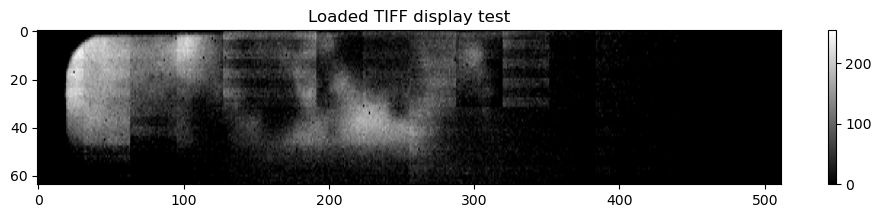

In [53]:
test_path = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260414\260414012\260414012000.tif"

img = load_gray(test_path)
disp = to_display_u8(img)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())
print("mean:", img.mean())
print("std:", img.std())

plt.figure(figsize=(12, 2))
plt.imshow(disp, cmap="gray", aspect="auto")
plt.title("Loaded TIFF display test")
plt.colorbar()
plt.show()

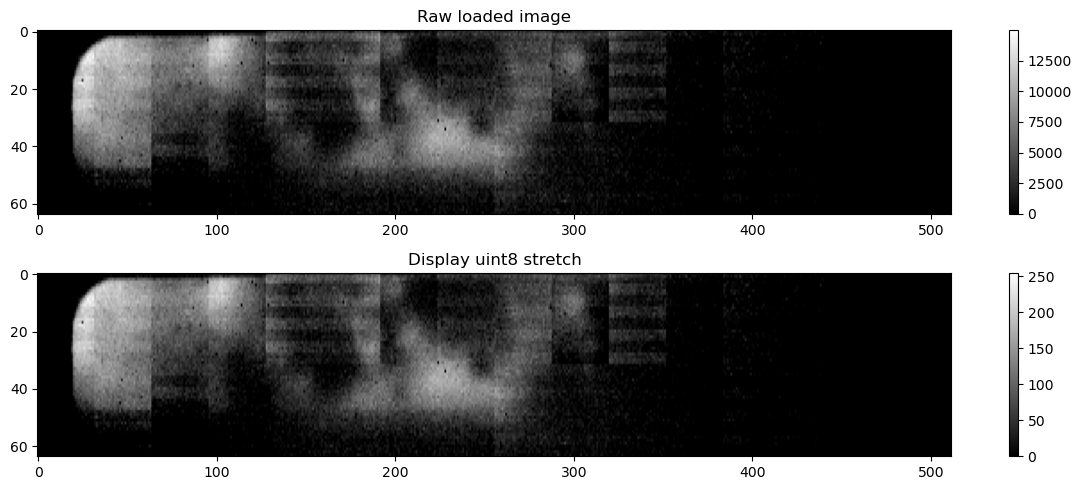

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.imshow(img, cmap="gray", aspect="auto")
plt.title("Raw loaded image")
plt.colorbar()

plt.subplot(2, 1, 2)
plt.imshow(disp, cmap="gray", aspect="auto")
plt.title("Display uint8 stretch")
plt.colorbar()

plt.tight_layout()
plt.show()

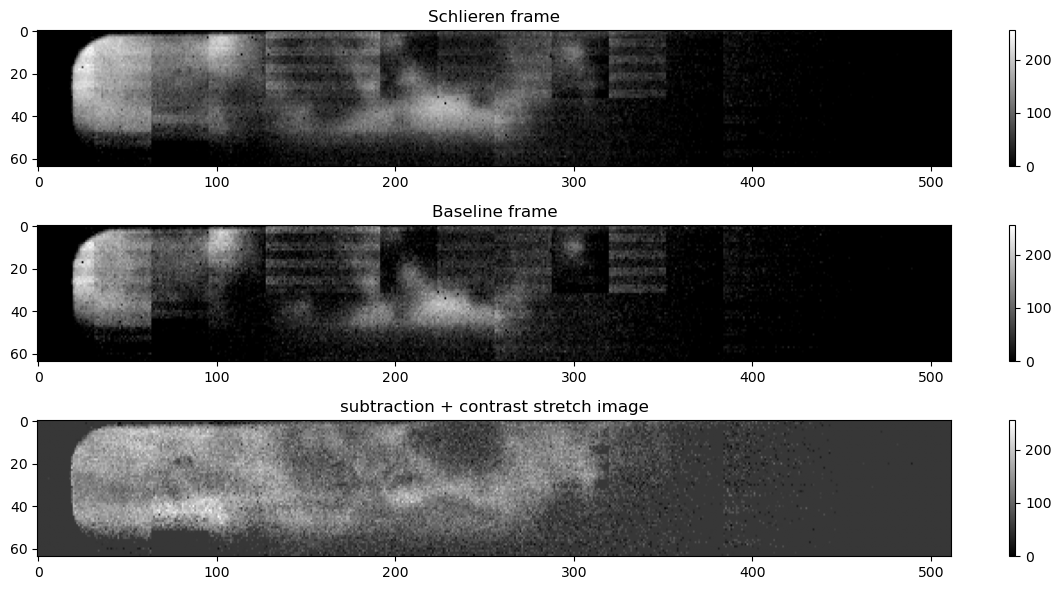

diff min: 0
diff max: 255
diff mean: 88.521240234375
diff std: 41.5417451471176


In [111]:
s = load_gray(r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260414\260414012\260414012025.tif")
b = load_gray(r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260414\260414003\260414003025.tif")

diff = subtract_background_signed(s, b)
diff = np.clip(contrast_stretch(diff), 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.imshow(to_display_u8(s), cmap="gray", aspect="auto")
plt.title("Schlieren frame")
plt.colorbar()

plt.subplot(3, 1, 2)
plt.imshow(to_display_u8(b), cmap="gray", aspect="auto")
plt.title("Baseline frame")
plt.colorbar()

plt.subplot(3, 1, 3)
plt.imshow(diff, cmap="gray", aspect="auto")
plt.title("subtraction + contrast stretch image")
plt.colorbar()

plt.tight_layout()
plt.show()

print("diff min:", diff.min())
print("diff max:", diff.max())
print("diff mean:", diff.mean())
print("diff std:", diff.std())

diff min: 0.0
diff max: 255.0
diff mean: 56.323273
diff std: 41.643436


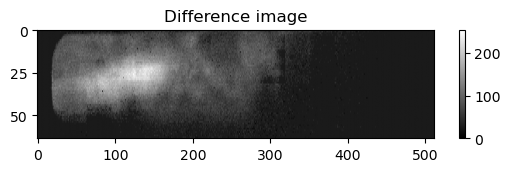

In [95]:
a = load_gray(r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260414\260414012 TEST\260414012020_proc.tif")

print("diff min:", a.min())
print("diff max:", a.max())
print("diff mean:", a.mean())
print("diff std:", a.std())

plt.subplot(3, 1, 3)
plt.imshow(a, cmap="gray", aspect="auto")
plt.title("Difference image")
plt.colorbar()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def show_baseline_comparison(
    baseline_dir,
    single_baseline_path,
    *,
    crop_box=None,
    pick_crop_interactively=False,
):
    baseline_dir = Path(baseline_dir)
    single_baseline_path = Path(single_baseline_path)



    # ---- choose crop ----
    if pick_crop_interactively:
        crop_box = select_crop_region(baseline_dir)

    if crop_box is None:
        raise ValueError("Provide crop_box or enable interactive crop.")

    # ---- compute averaged baseline ----
    mean_baseline = compute_mean_baseline(baseline_dir, crop_box)

    # ---- load single baseline ----
    single = load_gray(single_baseline_path)
    vmin = single.min()
    vmax = single.max()

    single_c = crop_image(single, crop_box)

    if single_c.shape != mean_baseline.shape:
        raise ValueError("Shape mismatch after cropping.")

    # ---- difference ----
    diff = subtract_background_signed(single_c, mean_baseline)

    # stretch diff for visualization only
    diff_view = contrast_stretch(diff)

    # ---- metrics ----
    print("Metrics:")
    print(" mean diff:", diff.mean())
    print(" std diff :", diff.std())
    print(" RMS diff :", np.sqrt(np.mean(diff**2)))

    # ---- display ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(single_c, cmap="gray")
    axes[0].set_title("Single Baseline")
    axes[0].axis("off")

    axes[1].imshow(mean_baseline, cmap="gray")
    axes[1].set_title("Averaged Baseline")
    axes[1].axis("off")

    axes[2].imshow(diff, cmap="gray")
    axes[2].set_title("Single − Mean (Contrast Stretched)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return single_c, mean_baseline, diff

In [ ]:
crop = (74, 254, 742, 100)

single, mean, diff = show_baseline_comparison(
    r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\Schlieren post processing\Schlieren data\260217\1us_1000fps_background",
    r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\Schlieren post processing\Schlieren data\260219\260219009\FILTERED.tif",
    crop_box=crop
    #pick_crop_interactively=True
)